In [21]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split

In [57]:
df = pd.read_csv("kc_house_data.csv", parse_dates = ['date'])
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [58]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [59]:
df.shape

(21613, 21)

A data set contains 21613 obervations with 20 features plus house price.
This is a huge dataset. Here are the details.

id

date: Date house was sold(String)

price: Price of the sold house

bedrooms: Numer of Bedrooms

bathrooms: Numer of bathrooms

sqft_living: Square footage of the living room

sqrt_lot: Square footage of the log

floors: Total floors in the house

waterfront: Whether the house has a view a waterfront(1: yes, 0: not)

view: unknown

condtion: Condition of the house

grade: unknown

sqft_above: Square footage of house apart from basement

sqft_basement: Square footage of the basement

yr_built: Built year

yr_renovated: Year when the house was renovated

zipcode: zipcode of the house

lat: Latitude coordinate

long Longitude coordinate

sqft_living15: Living room area in 2015(implies some renovations)

sqrt_lot15: Lot area in 2015(implies some renovations)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
id               21613 non-null int64
date             21613 non-null datetime64[ns]
price            21613 non-null float64
bedrooms         21613 non-null int64
bathrooms        21613 non-null float64
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null float64
waterfront       21613 non-null int64
view             21613 non-null int64
condition        21613 non-null int64
grade            21613 non-null int64
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
yr_built         21613 non-null int64
yr_renovated     21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
dtypes: datetime64[ns](1), float64(5), int64(15)
memory usage: 3.5 MB


In [61]:
df.isna().values.any()

False

In [62]:
df.isna().sum().sum()

0

In [63]:
df.isnull().values.any()

False

In [64]:
df.isnull().sum().sum()

0

There is no missing or null values and the data looks clean from NaN or Null. 

In [65]:
#Check for zeroes in the data
(df==0).sum().to_frame().T

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,0,0,13,10,0,0,0,21450,19489,...,0,0,13126,0,20699,0,0,0,0,0


Some of the houses do not have bedrooms and bathrooms. Domain expert will be able to describe well about this. 
But the possibility of having no bathrooms looks very unlikely. Hence substitue bedrrooms =0 and bathrooms =0 with mean value.

'waterfront', 'view', 'sqft_basement', 'yr_renovated' - having zero looks valid as som houses may not have these

In [68]:
print('date', df['date'].nunique())

date 372


In [69]:
print('date', df['date'].min())

date 2014-05-02 00:00:00


In [70]:
print('date', df['date'].max())

date 2015-05-27 00:00:00


In [71]:
#id is unique to each user. Date is within a certain range 2014 May to 2015 May
#It may not have effect on house pricing within the given small range.
#yr_built is important while selling the house.
#A year of change in selling date may not affect much in pricing.
#Suggest to use expert domain knowlegde
#Hence dropping the columns

df.drop(['id', 'date'], axis=1, inplace=True)

In [73]:
#Make zero values (missing data in bathrooms and bedrooms) as mean values
#Ideally it will be nice to use numbers based on area and size of the house, but to keep it simple, we will use mean for now
df=df.replace({'bedrooms': {0: df.bedrooms.mean()}}) 
df=df.replace({'bathrooms': {0: df.bathrooms.mean()}}) 

In [75]:
#recheck
(df==0).sum().to_frame().T

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,0,0,0,0,0,21450,19489,0,0,0,13126,0,20699,0,0,0,0,0


In [76]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [84]:
df.describe().T
#Look at every column to understand if the data is valid

,count,mean,std,min,25%,50%,75%,max
price,21613.0,540088.141767,367127.196483,75000.0000,321950.000,450000.0000,645000.000,7.700000e+06
bedrooms,21613.0,3.372869,0.926378,1.0000,3.000,3.0000,4.000,3.300000e+01
bathrooms,21613.0,2.115736,0.768818,0.5000,1.750,2.2500,2.500,8.000000e+00
sqft_living,21613.0,2079.899736,918.440897,290.0000,1427.000,1910.0000,2550.000,1.354000e+04
sqft_lot,21613.0,15106.967566,41420.511515,520.0000,5040.000,7618.0000,10688.000,1.651359e+06
floors,21613.0,1.494309,0.539989,1.0000,1.000,1.5000,2.000,3.500000e+00
sqft_above,21613.0,1788.390691,828.090978,290.0000,1190.000,1560.0000,2210.000,9.410000e+03
sqft_basement,21613.0,291.509045,442.575043,0.0000,0.000,0.0000,560.000,4.820000e+03
yr_built,21613.0,1971.005136,29.373411,1900.0000,1951.000,1975.0000,1997.000,2.015000e+03
yr_renovated,21613.0,84.402258,401.679240,0.0000,0.000,0.0000,0.000,2.015000e+03


In [85]:
df.median()

price            450000.0000
bedrooms              3.0000
bathrooms             2.2500
sqft_living        1910.0000
sqft_lot           7618.0000
floors                1.5000
waterfront            0.0000
view                  0.0000
condition             3.0000
grade                 7.0000
sqft_above         1560.0000
sqft_basement         0.0000
yr_built           1975.0000
yr_renovated          0.0000
zipcode           98065.0000
lat                  47.5718
long               -122.2300
sqft_living15      1840.0000
sqft_lot15         7620.0000
dtype: float64

In [86]:
#looks like most fetaures has max values as outliers having huge value which is far away from median
#keep them as is now. Will do graphics observations and then decide to handle outliers, if any.

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21613 entries, 0 to 21612
Data columns (total 19 columns):
price            21613 non-null float64
bedrooms         21613 non-null float64
bathrooms        21613 non-null float64
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null float64
waterfront       21613 non-null category
view             21613 non-null category
condition        21613 non-null category
grade            21613 non-null category
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
yr_built         21613 non-null int64
yr_renovated     21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
dtypes: category(4), float64(6), int64(9)
memory usage: 2.7 MB


In [88]:
for col in df.columns:
    print (col, " : ", df[col].nunique())

price  :  4028
bedrooms  :  13
bathrooms  :  30
sqft_living  :  1038
sqft_lot  :  9782
floors  :  6
waterfront  :  2
view  :  5
condition  :  5
grade  :  12
sqft_above  :  946
sqft_basement  :  306
yr_built  :  116
yr_renovated  :  70
zipcode  :  70
lat  :  5034
long  :  752
sqft_living15  :  777
sqft_lot15  :  8689


In [89]:
# convert the categorical items to correct tyeprint('waterfront', df['waterfront'].unique().tolist())
print('view', df['view'].unique().tolist())
print('condition', df['condition'].unique().tolist())
print('grade', df['grade'].unique().tolist())

view [0, 3, 4, 2, 1]
condition [3, 5, 4, 1, 2]
grade [7, 6, 8, 11, 9, 5, 10, 12, 4, 3, 13, 1]


In [90]:
# convert the categorical items to correct type

#df.waterfront = df.waterfront.astype("category")
#df.view = df.view.astype("category")
#df.condition = df.condition.astype("category")
#df.grade = df.grade.astype("category")
#df = pd.get_dummies(df,drop_first=True)


df.waterfront = pd.Categorical(df.waterfront)
df.view = pd.Categorical(df.view)
df.condition = pd.Categorical(df.condition)
df.grade = pd.Categorical(df.grade)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21613 entries, 0 to 21612
Data columns (total 19 columns):
price            21613 non-null float64
bedrooms         21613 non-null float64
bathrooms        21613 non-null float64
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null float64
waterfront       21613 non-null category
view             21613 non-null category
condition        21613 non-null category
grade            21613 non-null category
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
yr_built         21613 non-null int64
yr_renovated     21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
dtypes: category(4), float64(6), int64(9)
memory usage: 2.7 MB


In [92]:
#we can also drop missing values. but won't do now. use them with mean values.
#df['bedrooms'].replace(0,np.nan, inplace=True)
#df['bathrooms'].replace(0,np.nan, inplace=True)
#df.dropna(inplace=True)
#df.reset_index(drop=True)

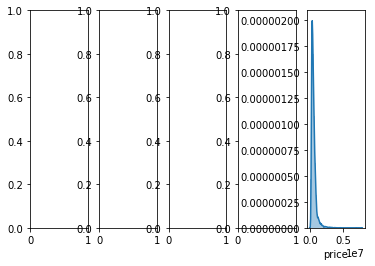

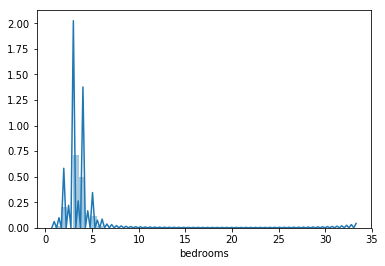

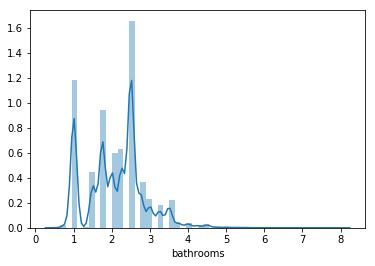

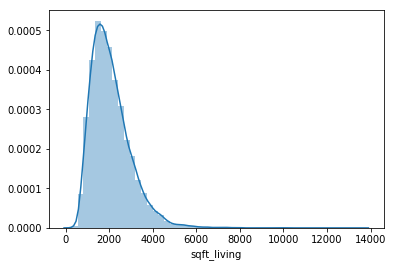

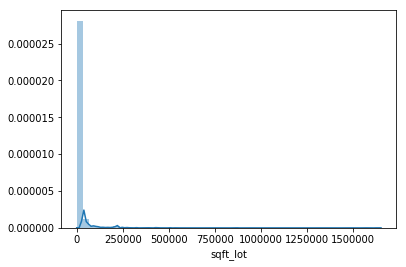

In [116]:
fig, axes = plt.subplots()

for ax, col in zip(axes, df.columns):
    sns.distplot(df[col])
    plt.show()

IndexError: index 2 is out of bounds for axis 1 with size 2

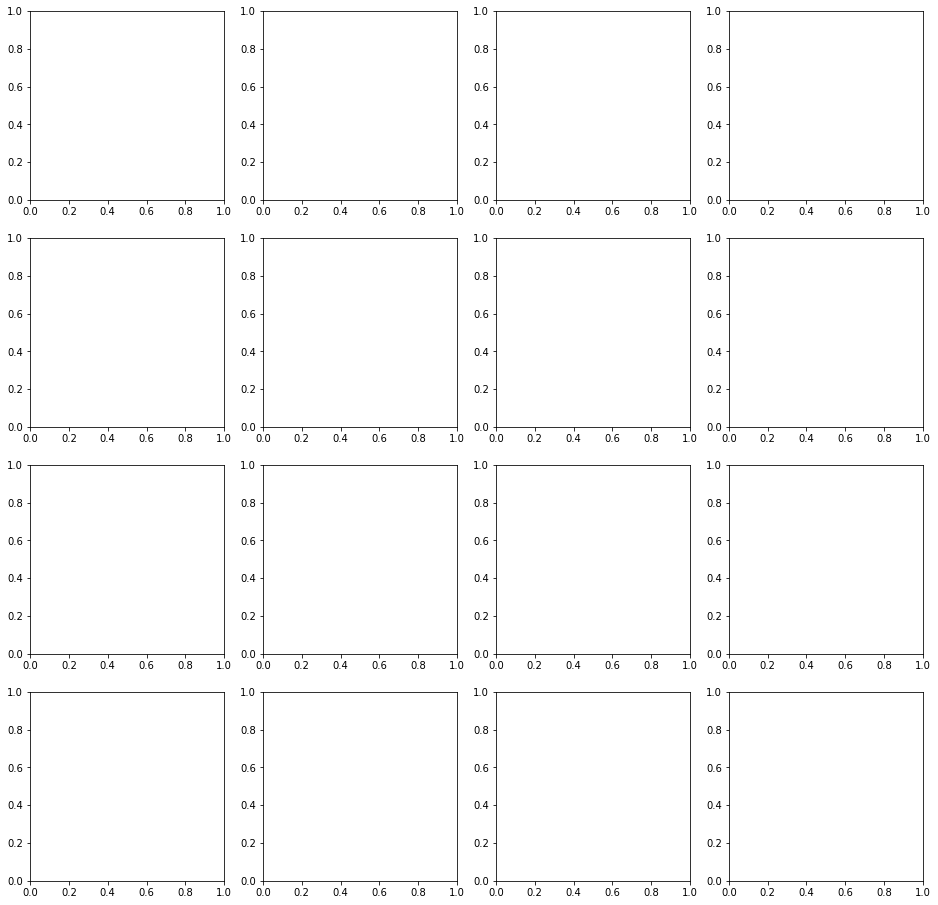

In [99]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16,16))
#for col in df.columns():
#    sns.distplot(df.'col', bins = 20, ax=ax[0,0]) 
for i, column in enumerate(df.columns):
    sns.distplot(df[column],ax=ax[i//4,i%4])

In [20]:
ax = df['class'].value_counts().plot(kind='bar',
                                    figsize=(10,5),
                                    title="No of each type of Vehicle")
ax.set_xlabel("Vehicle Type")
ax.set_ylabel("Count")
plt.show()

KeyError: 'class'

In [ ]:
df.dropna(inplace=True)
df.isna().values.any()

In [ ]:
df.isna().sum().sum()